# Mean reversion (Pairs trading)
When two assets are said to be cointegrated, a linear combination of the time series of these two assets produces a stationary time series. This means that these assets will fluctuate around a long-run equilibrium, and their spread (the linear combination of their prices) will have a constant mean and variance. When this spread deviates significantly from its mean, we can construct a strategy that bets on reversion back to the mean, potentially generating profits. In this project, I use the Engle-Granger cointegration test to identify cointegrated pairs of stocks from a basket of arbitrarily selected companies in different sectors, and then trade deviations of the spread using z-score thresholds.

In [143]:
# Data from 5 years ago
# Close data will be used as the main data

import warnings
warnings.filterwarnings("ignore")   # For cleanliness' sake

import pandas as pd
import pandas_datareader as pdr
from datetime import datetime
import yfinance as yf

def get_histData(tickers):
    data = pd.DataFrame()
    names = list()
    for i in tickers:
        df = pd.DataFrame(yf.download(i, start=datetime(2023, 8, 13), end=datetime(2025, 8, 13), progress = False))
        data = pd.concat([data, df['Close']], axis = 1)
        names.append(i)
    data.columns = names
    return data

TICKERS = [
    "AAPL","GOOG","SPY","NFLX","SNAP",   # tech + social
    "MSFT","AMZN","META","TSLA","NVDA",  # big tech
    "JPM","GS",                          # banks
    "XOM","CVX",                         # oil majors
    "WMT","NKE","BA"                     # consumer + industrial
]
d = get_histData(TICKERS)
print(d.shape)
# Most Recent Data
d.tail()

(501, 17)


,AAPL,GOOG,SPY,NFLX,SNAP,MSFT,AMZN,META,TSLA,NVDA,JPM,GS,XOM,CVX,WMT,NKE,BA
Date,,,,,,,,,,,,,,,,,
2025-08-06,213.008255,196.744156,632.780029,1178.479980,7.78,524.078491,222.309998,771.989990,319.910004,179.419998,291.350006,720.880981,105.528023,151.097961,103.119156,75.089775,225.039993
2025-08-07,219.780563,197.103821,632.250000,1180.369995,7.54,519.985229,223.130005,761.830017,322.269989,180.770004,286.940002,715.907593,104.973183,151.473785,102.879715,73.965607,227.330002
2025-08-08,229.090012,201.909531,637.179993,1211.640015,7.41,521.183228,222.690002,769.299988,329.649994,182.699997,288.760010,717.429504,105.815353,153.303406,103.488297,73.806442,229.119995
2025-08-11,227.179993,201.449951,635.919983,1218.310059,7.19,520.913696,221.300003,765.869995,339.029999,182.059998,289.559998,715.410278,104.854294,151.760590,103.687828,73.637314,225.960007
2025-08-12,229.649994,203.977692,642.690002,1225.280029,7.27,528.371399,221.470001,790.000000,340.839996,183.160004,292.850006,739.421753,105.151520,152.739700,103.378548,74.512772,232.610001


I apply the Engle-Granger two step test: regress one log price series on the other, then test whether the residuals are stationary (i.e., do not contain a unit root). If the residuals are stationary, the pair is considered cointegrated. While unit roots in non-stationary price series can often be handled by differencing, here the focus is specifically identifying stationary spreads suitable for trading.

In [146]:
import numpy as np
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

PCOFF = 0.05

def ols_beta(y: pd.Series, x: pd.Series):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    a, b = model.params
    resid = y - (a + b * x)
    return a, b, resid

# This project will be using log prices for cointegration and for determining the spread of the pair 
# as they linearize features and produce a better model.

def find_cointegrated_pairs(prices: pd.DataFrame, pval_cutoff=0.05):
    logp = np.log(prices.dropna())
    rows = []
    for a, b in itertools.combinations(logp.columns, 2):
        y, x = logp[a].dropna(), logp[b].dropna()
        idx = y.index.intersection(x.index)
        _, pval, _ = coint(y.loc[idx], x.loc[idx], trend="c")
        if np.isfinite(pval):
            a_hat, b_hat, _ = ols_beta(y.loc[idx], x.loc[idx])
            rows.append((pval, a, b, a_hat, b_hat))
    df = pd.DataFrame(rows, columns=["pval","y","x","alpha","beta"]).sort_values("pval")
    return df[df["pval"] <= pval_cutoff].reset_index(drop=True)

coint_df = find_cointegrated_pairs(d, pval_cutoff=PCOFF)

if coint_df.empty:
    print("No cointegrated pairs found at cutoff. Consider widening universe or p-value.")

print("Top cointegrated pairs:\n", coint_df.head(10).to_string(index=False))

Top cointegrated pairs:
     pval    y    x     alpha      beta
0.008756 META  JPM -0.038024  1.175575
0.012589  XOM   BA  6.109778 -0.275576
0.014735 NFLX  JPM -1.526399  1.521764
0.038994  CVX   BA  5.354170 -0.072485
0.044557 AMZN META  1.559925  0.586415
0.045627  SPY META  3.596860  0.430349
0.046865  CVX  WMT  4.839133  0.031842


For this project, I will use META and JPM assets for pairs trading. With a p-value of less than 0.01, we reject the null hypothesis of no cointegration.

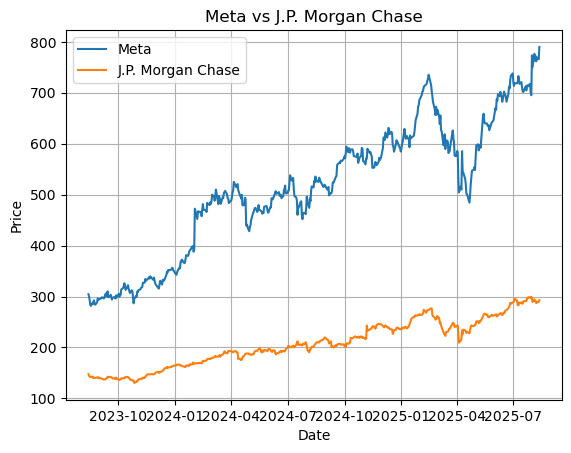

In [149]:
import matplotlib.pyplot as plt

META = d['META']
JPM = d['JPM']

plt.plot(META, label="Meta")
plt.plot(JPM, label="J.P. Morgan Chase")

plt.legend()
plt.title("Meta vs J.P. Morgan Chase")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

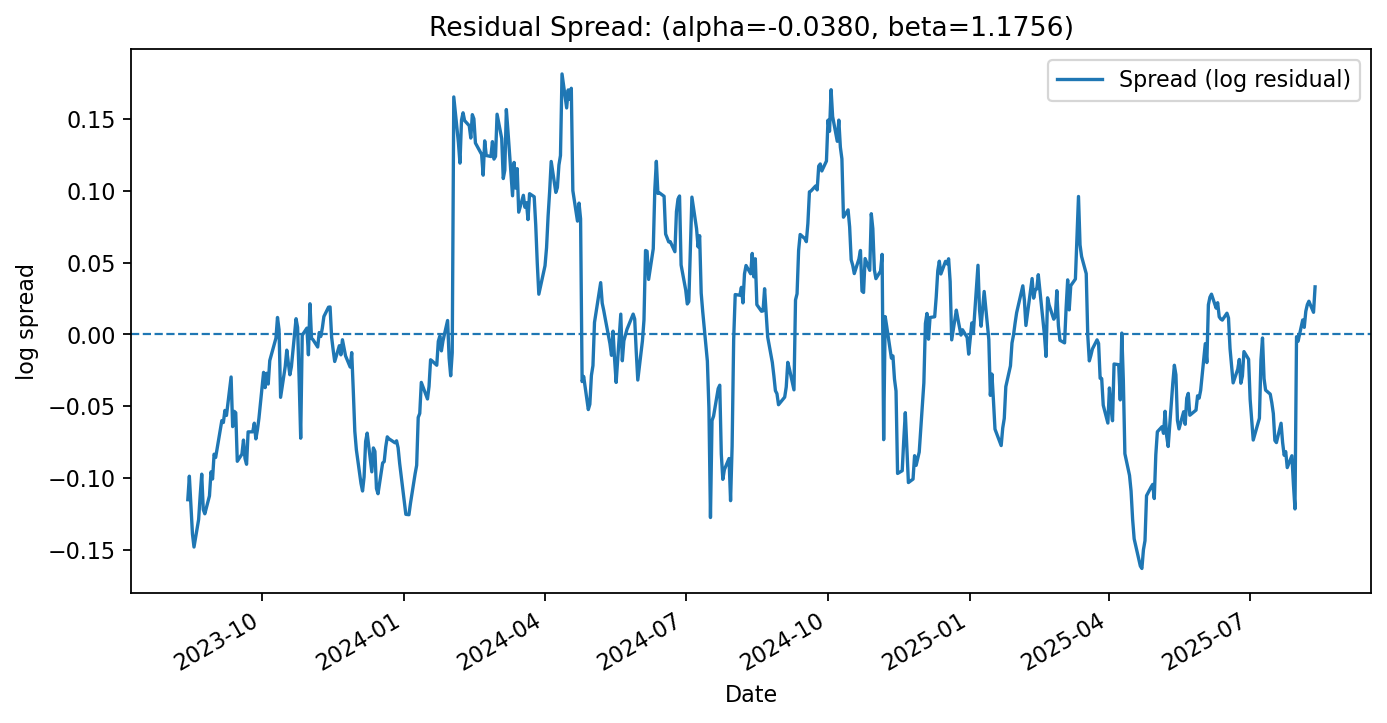

In [151]:
# Graphically representing the subsequent time series to verify that it is indeed stationary

spread = np.log(d['META']) - (-0.038024 + 1.175575 * np.log(d['JPM']))
plt.figure(figsize=(10,5), dpi=160)
spread.plot(label="Spread (log residual)")
plt.axhline(0, ls="--", lw=1)
plt.title(f"Residual Spread: (alpha={-0.038024:.4f}, beta={1.175575:.4f})")
plt.legend()
plt.xlabel("Date"); plt.ylabel("log spread")
plt.show()

In [153]:
logy = np.log(META)
logx = np.log(JPM)

In [155]:
def rolling_ols_spread(logy, logx, window=252):
    idx = logy.index.intersection(logx.index)
    y, x = logy.loc[idx], logx.loc[idx]
    alpha = pd.Series(index=idx, dtype=float)
    beta  = pd.Series(index=idx, dtype=float)
    resid = pd.Series(index=idx, dtype=float)

    for i in range(window, len(idx)):
        ys = y.iloc[i-window:i]
        xs = x.iloc[i-window:i]
        X = sm.add_constant(xs)
        model = sm.OLS(ys, X).fit()
        a, b = model.params
        alpha.iloc[i], beta.iloc[i] = a, b
        resid.iloc[i] = y.iloc[i] - (a + b * x.iloc[i])

    mu = resid.rolling(window, min_periods=window//2).mean()
    sd = resid.rolling(window, min_periods=window//2).std(ddof=1)
    z  = (resid - mu) / sd
    out = pd.DataFrame({"alpha":alpha, "beta":beta, "resid":resid, "mu":mu, "sigma":sd, "z":z}).dropna()
    return out

roll_win = 126  # ~1y
model = rolling_ols_spread(logy, logx, window=roll_win)
model.tail(3)

,alpha,beta,resid,mu,sigma,z
Date,,,,,,
2025-08-08,-0.109718,1.183028,0.052640,-0.021665,0.055249,1.344908
2025-08-11,-0.130841,1.186850,0.044359,-0.021893,0.054913,1.206494
2025-08-12,-0.146273,1.189625,0.061643,-0.022104,0.054536,1.535629


In [157]:
ENTRY_Z = 2.0
EXIT_Z  = 0.5
STOP_Z  = 4.0

pos = pd.Series(0, index=model.index, dtype=int)
in_trade = False

for t in model.index:
    z = model.at[t, "z"]
    if not in_trade:
        if z >= ENTRY_Z:
            pos.at[t] = -1   # short spread: short y, long beta*x
            in_trade = True
        elif z <= -ENTRY_Z:
            pos.at[t] = +1   # long spread: long y, short beta*x
            in_trade = True
    else:
        prev = pos[pos.index < t]
        side = prev.iloc[-1] if len(prev) else 0
        if abs(z) <= EXIT_Z or abs(z) >= STOP_Z:
            pos.at[t] = 0
            in_trade = False
        else:
            pos.at[t] = side

pos = pos.replace(to_replace=0, method="ffill").fillna(0)
pos.tail(3)

Date
2025-08-08    1
2025-08-11    1
2025-08-12    1
dtype: int64

In [159]:
ry = logy.diff().reindex(model.index)
rx = logx.diff().reindex(model.index)
beta = model["beta"].ffill()

# Spread return
spread_ret = ry - beta * rx

# Position one day late to avoid look-ahead (execute next bar)
pnl_gross = pos.shift(1).fillna(0) * spread_ret

# Simple slippage model: 1 bps per side on position change
SLIPPAGE_BPS = 1.0
trades = pos.diff().abs().fillna(0)
slippage = trades * (SLIPPAGE_BPS / 10000.0)

ret_net = (pnl_gross - slippage).fillna(0.0)
equity = (1.0 + ret_net).cumprod()

bt = pd.DataFrame({
    "pos": pos,
    "z": model["z"],
    "beta": beta,
    "spread_ret": spread_ret,
    "gross_ret": pnl_gross,
    "slippage": slippage,
    "net_ret": ret_net,
    "equity": equity
}).dropna()
bt.tail(3)

,pos,z,beta,spread_ret,gross_ret,slippage,net_ret,equity
Date,,,,,,,,
2025-08-08,1,1.344908,1.183028,0.002278,0.002278,0.0,0.002278,1.621415
2025-08-11,1,1.206494,1.186850,-0.007752,-0.007752,0.0,-0.007752,1.608846
2025-08-12,1,1.535629,1.189625,0.017580,0.017580,0.0,0.017580,1.637129


Sharpe: 1.412
Max DD: -17.4%
Trades: 2


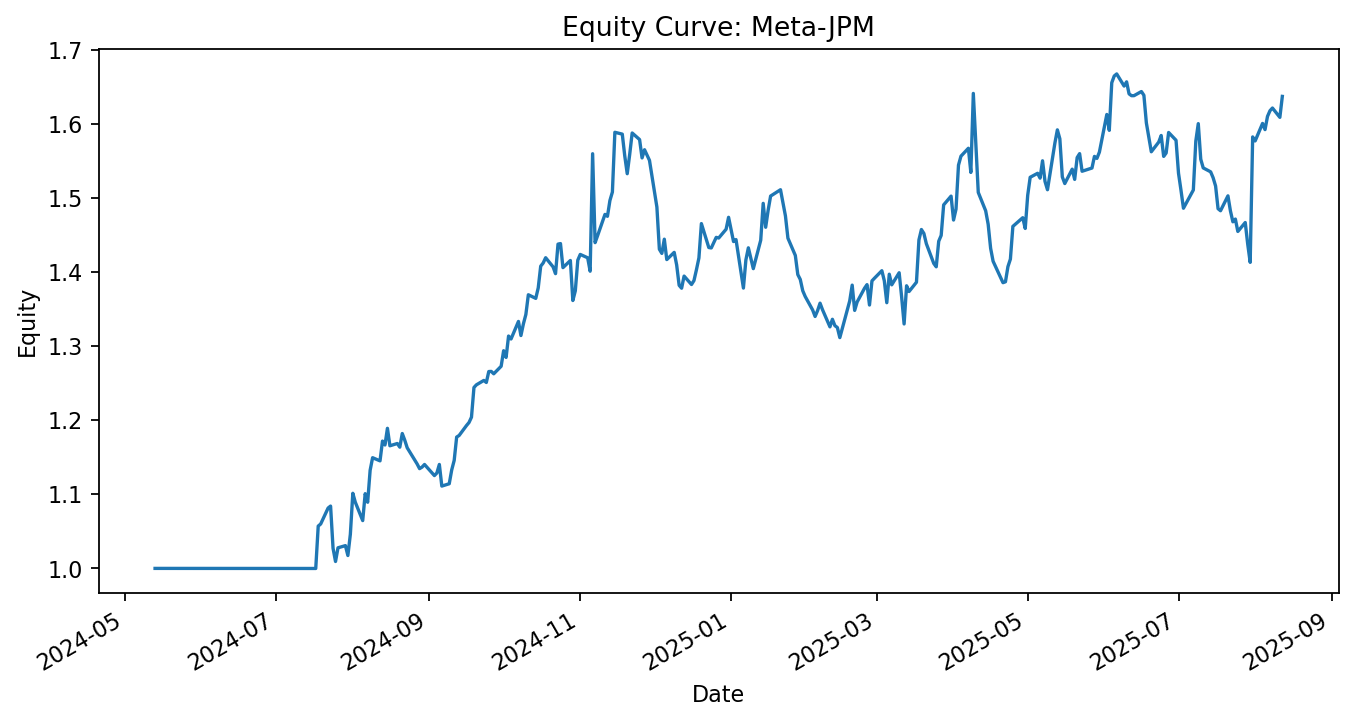

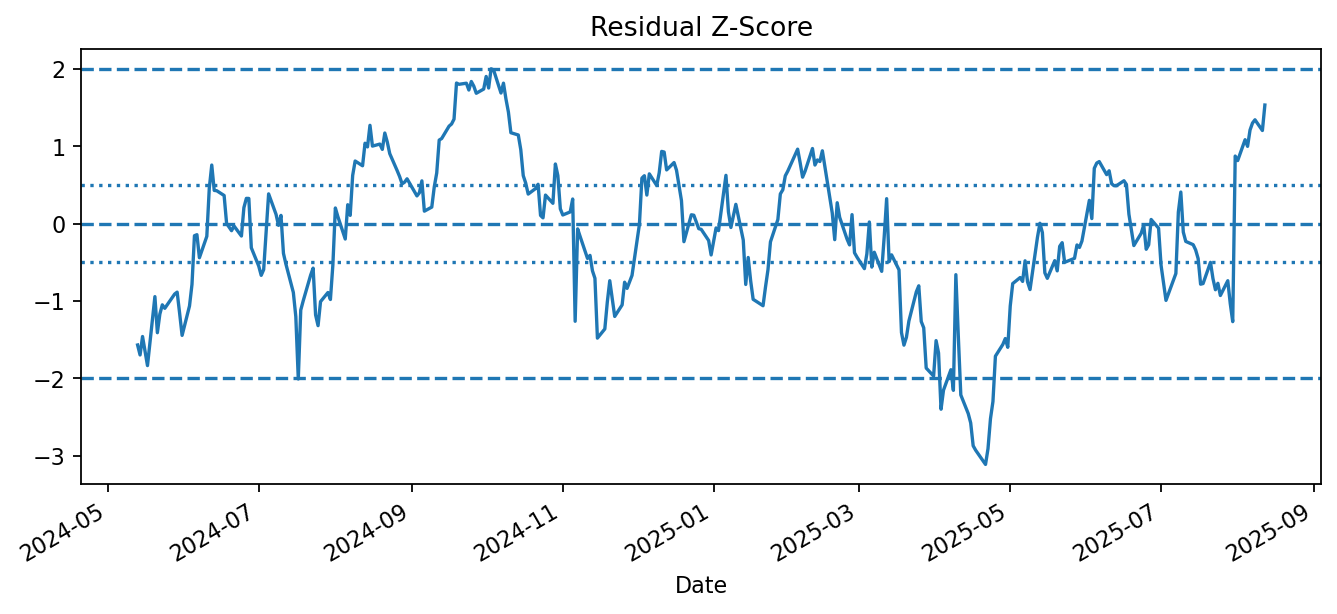

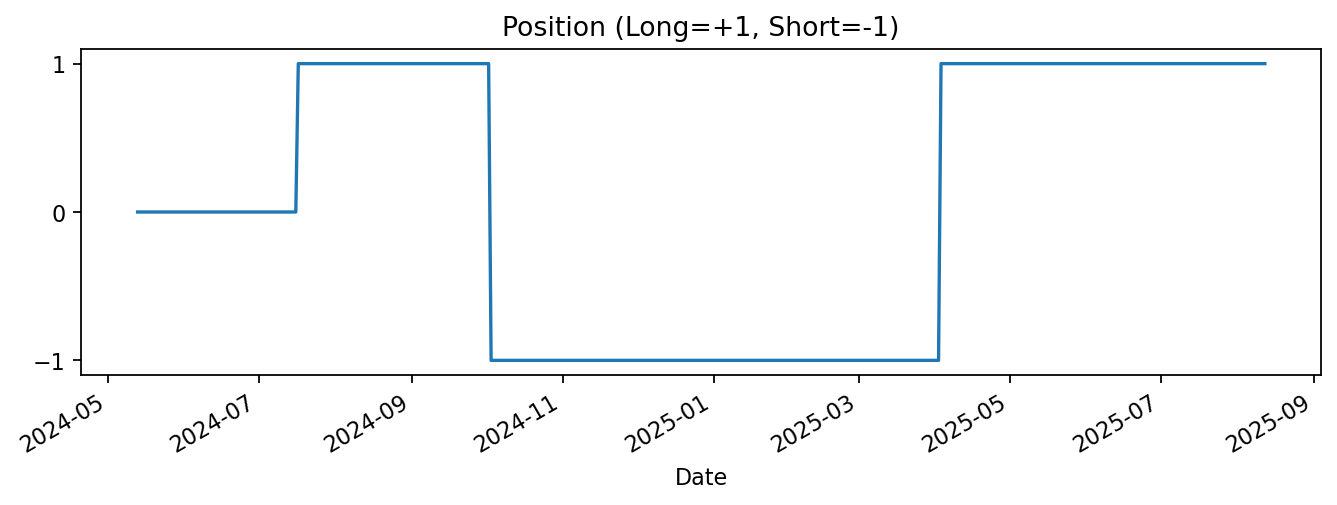

In [161]:
def sharpe(r, periods=252):
    r = r.dropna()
    if len(r) < 2 or r.std(ddof=1) == 0: return np.nan
    return float(r.mean()*periods / (r.std(ddof=1)*np.sqrt(periods)))

def max_drawdown(eq):
    peak = eq.cummax()
    dd = eq/peak - 1.0
    return float(dd.min())

print("Sharpe:", round(sharpe(bt["net_ret"]), 3))
print("Max DD:", f'{100*max_drawdown(bt["equity"]):.1f}%')
print("Trades:", int(bt["pos"].diff().abs().sum()/2))  # rough count (entry+exit)

plt.figure(figsize=(10,5), dpi=160); bt["equity"].plot(title=f"Equity Curve: Meta-JPM")
plt.xlabel("Date"); plt.ylabel("Equity"); plt.show()

plt.figure(figsize=(10,4), dpi=160); bt["z"].plot(title="Residual Z-Score")
plt.axhline(0, ls="--"); plt.axhline(ENTRY_Z, ls="--"); plt.axhline(-ENTRY_Z, ls="--")
plt.axhline(EXIT_Z, ls=":"); plt.axhline(-EXIT_Z, ls=":"); plt.show()

plt.figure(figsize=(10,3), dpi=160); bt["pos"].plot(title="Position (Long=+1, Short=-1)")
plt.yticks([-1,0,1]); plt.show()

As a benchmark, I compare the strategy's quity curve to a buy-and-hold investment in the S&P 500. The pairs strategy achieves higher cumulative returns over the sample and exhibits shallower drawdowns. This suggests it generates value not only in terms of total return, but also risk adjusted performance.

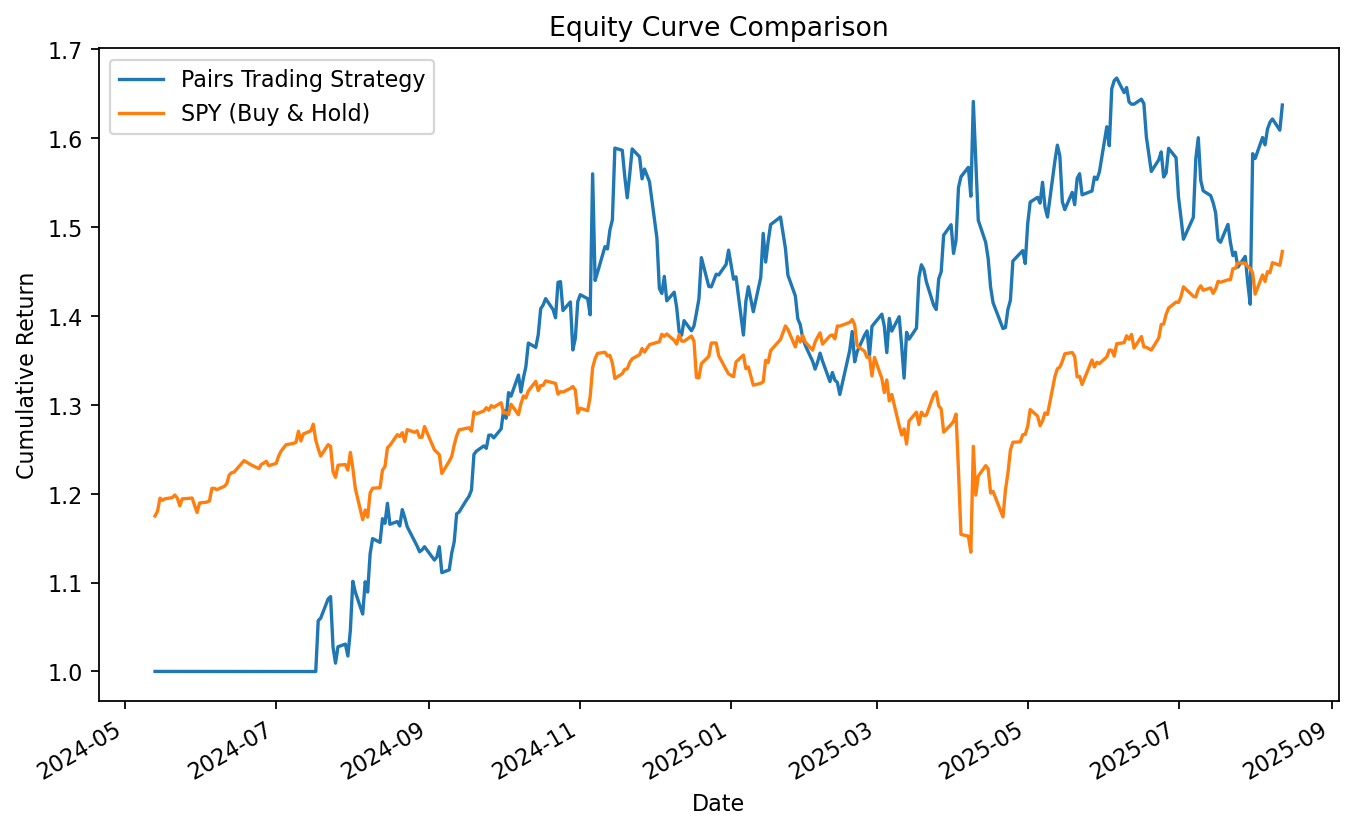

In [164]:
bench = d['SPY'].dropna()
bench_ret = bench.pct_change().dropna()
bench_eq = (1 + bench_ret).cumprod()

plt.figure(figsize=(10,6), dpi=160)
bt['equity'].plot(label="Pairs Trading Strategy")
bench_eq.reindex(bt.index).plot(label="SPY (Buy & Hold)")
plt.legend()
plt.title("Equity Curve Comparison")
plt.ylabel("Cumulative Return")
plt.show()